# Pesquisa em IA e adoção corporativa

**Projeto Aplicado — Análise e Visualização de Dados em Python**  
**Integrantes:** _preencher nomes_  
**Fonte principal:** Stanford HAI, *AI Index Report 2026*.

Este notebook relaciona a evolução da produção mundial de publicações de IA em Ciência da Computação com o uso de IA reportado por organizações. O recorte combina dados dos capítulos **1. Research and Development** e **4. Economy** e trata a relação como **associação exploratória**, não como evidência causal.



Nos oito anos coincidentes entre as séries (2017–2024), as publicações mundiais de IA em Ciência da Computação passaram de **116,9 mil** para **257,9 mil** (**+120,5%**) e a parcela de organizações que reportou usar IA em ao menos uma função passou de **20%** para **78%** (**+58 pontos percentuais**).

A correlação entre os **níveis anuais** foi positiva e alta (**Pearson = 0,81**), mas caiu para **0,28** quando comparamos as **variações anuais**. A evidência, portanto, mostra duas tendências que avançam no mesmo período, mas não demonstra que o aumento da pesquisa tenha causado a adoção corporativa.

O resultado deve ser lido com cautela: são apenas oito observações anuais, as fontes e populações são diferentes, e a série de adoção provém de pesquisas anuais autorrelatadas.


## 1. Contexto e métodos

### 1.1 Problema e pergunta analítica

O *AI Index Report 2026*, produzido pelo Stanford Institute for Human-Centered Artificial Intelligence (HAI), reúne indicadores sobre pesquisa, economia e outros domínios da inteligência artificial. O problema investigado é a possível associação temporal entre a expansão da pesquisa em IA e sua difusão no ambiente corporativo.

**Pergunta central:** como evoluíram as publicações mundiais de IA em Ciência da Computação e a proporção de organizações que usam IA, e que associação exploratória aparece nos anos coincidentes de 2017 a 2024?

**Hipótese exploratória:** ambas as séries podem crescer conjuntamente conforme a IA se desenvolve e se difunde. Entretanto, uma correlação entre níveis pode ser elevada apenas porque as duas variáveis apresentam tendência temporal. Por isso, além dos níveis, serão comparadas as primeiras diferenças (variações de um ano para o seguinte).

### 1.2 Pressupostos-chave

- A unidade de análise da correlação é o **ano**, não a empresa, o artigo ou o país.
- Publicações são medidas em milhares; adoção é a proporção de respondentes cuja organização usa IA em ao menos uma função.
- Os dados são agregados globais de fontes independentes e não constituem observações pareadas.
- Correlação descreve associação; não identifica direção causal nem controla investimento, custo computacional, regulação ou outros fatores.


### 1.3 Origem e contexto dos dados

A série de publicações deriva do **OpenAlex** e considera publicações em inglês classificadas como relacionadas à IA pelo CSO Classifier. O próprio relatório ressalta que volume não mede qualidade e que nem toda pesquisa aparece em bases indexadas.

A série de adoção deriva das pesquisas anuais *State of AI*, da **McKinsey & Company**. Para 2025, a pesquisa online recebeu 1.993 respostas de 105 países, abrangendo regiões, setores, portes e funções; os resultados foram ponderados pela contribuição de cada país ao PIB global. O relatório classifica os resultados autorrelatados como direcionais, não abrangentes, e reúne as edições anteriores para formar a série histórica.

Para cumprir a etapa de codificação categórica, também usamos a composição das publicações de IA por **setor** e **área geográfica** em 2024.

**Arquivos escolhidos**

| Figura | Arquivo | Papel na análise |
|---|---|---|
| 1.6.1 | `1. Research and Development/Data/fig_1.6.1.csv` | Volume e participação das publicações de IA, 2013–2024 |
| 1.6.9 | `1. Research and Development/Data/fig_1.6.9.csv` | Composição setorial em EUA, Europa e China, 2024 |
| 4.3.1 | `4. Economy/Data/fig_4.3.1(1).csv` | Uso organizacional de IA, 2017–2025, e de IA generativa, 2023–2025 |


## 2. Dados

### 2.1 Bibliotecas, estilo e caminhos

O código usa `pandas`, `numpy`, `matplotlib` e `scikit-learn`, conforme o escopo da disciplina. Os caminhos são relativos à pasta do projeto; os arquivos originais não são alterados.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import OneHotEncoder

COLORS = {
    "blue": "#2864A8",
    "gold": "#D49B2A",
    "orange": "#D56A3A",
    "olive": "#6E7F3F",
    "pink": "#B45A7A",
    "charcoal": "#29323A",
    "gray": "#8A949C",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["charcoal"],
    "axes.titleweight": "bold",
    "axes.labelcolor": COLORS["charcoal"],
    "text.color": COLORS["charcoal"],
    "xtick.color": COLORS["charcoal"],
    "ytick.color": COLORS["charcoal"],
    "grid.color": "#D9DEE2",
    "grid.linewidth": 0.7,
    "font.size": 10,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "AI_INDEX_REPORT_2026").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "AI_INDEX_REPORT_2026"
PATH_PUBLICATIONS = DATA_ROOT / "1. Research and Development" / "Data" / "fig_1.6.1.csv"
PATH_SECTORS = DATA_ROOT / "1. Research and Development" / "Data" / "fig_1.6.9.csv"
PATH_ADOPTION = DATA_ROOT / "4. Economy" / "Data" / "fig_4.3.1(1).csv"

for path in [PATH_PUBLICATIONS, PATH_SECTORS, PATH_ADOPTION]:
    if not path.is_file():
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")

print(f"Raiz do projeto: {PROJECT_ROOT}")
print("Três arquivos de entrada localizados.")


Raiz do projeto: C:\Users\carla\VSCode_Projects\Trabalho_Visualizacao
Três arquivos de entrada localizados.


### 2.2 Leitura e caracterização estrutural

O carregamento abaixo registra dimensões, tipos e uma amostra limitada de cada arquivo. Os nomes originais das colunas são preservados nesta etapa para manter a rastreabilidade.


In [2]:
publications_raw = pd.read_csv(PATH_PUBLICATIONS)
sectors_raw = pd.read_csv(PATH_SECTORS)
adoption_raw = pd.read_csv(PATH_ADOPTION)

datasets = {
    "Publicações": publications_raw,
    "Setores": sectors_raw,
    "Adoção": adoption_raw,
}

structure = pd.DataFrame([
    {
        "conjunto": name,
        "registros": len(frame),
        "atributos": frame.shape[1],
        "colunas": ", ".join(frame.columns),
    }
    for name, frame in datasets.items()
])
display(structure)

for name, frame in datasets.items():
    print(f"\n{name} — tipos")
    display(frame.dtypes.astype(str).rename("tipo").to_frame())
    display(frame.head(4))


,conjunto,registros,atributos,colunas
0,Publicações,24,2,"Year, Number of AI publications in CS (in thou..."
1,Setores,12,3,"AI Publications (% of Total), Sector, Label"
2,Adoção,12,3,"Year, % of respondents, Label"



Publicações — tipos


,tipo
Year,int64
Number of AI publications in CS (in thousands),float64


,Year,Number of AI publications in CS (in thousands)
0,2013,101.885
1,2014,104.409
2,2015,105.741
3,2016,107.269



Setores — tipos


,tipo
AI Publications (% of Total),float64
Sector,str
Label,str


,AI Publications (% of Total),Sector,Label
0,0.508,Academia,United States
1,0.245,Industry,United States
2,0.131,Nonprofit,United States
3,0.116,Government,United States



Adoção — tipos


,tipo
Year,int64
% of respondents,float64
Label,str


,Year,% of respondents,Label
0,2023,0.330,GenAI
1,2024,0.710,GenAI
2,2025,0.790,GenAI
3,2017,0.200,AI


**Dicionário dos atributos relevantes**

- `Year`: ano da observação.
- `Number of AI publications in CS (in thousands)`: o arquivo reúne, na mesma coluna, a contagem em milhares e a participação das publicações de IA no total de Ciência da Computação.
- `% of respondents`: proporção dos respondentes que reportaram uso organizacional de IA ou IA generativa.
- `Label` no arquivo de adoção: identifica as séries `AI` e `GenAI`.
- `AI Publications (% of Total)`: participação de cada setor no total regional de publicações de IA em 2024.
- `Sector` e `Label` no arquivo setorial: setor de origem e área geográfica, respectivamente.


## 3. Qualidade e preparação dos dados

### 3.1 Valores ausentes, duplicidades e cardinalidade

A auditoria distingue duplicatas exatas de repetições de uma chave parcial. Um ano repetido pode ser legítimo quando o arquivo contém mais de uma métrica ou série.


In [3]:
def quality_report(frame, name):
    return pd.DataFrame({
        "conjunto": name,
        "atributo": frame.columns,
        "tipo": [str(frame[column].dtype) for column in frame.columns],
        "nulos": [int(frame[column].isna().sum()) for column in frame.columns],
        "nulos_%": [round(100 * frame[column].isna().mean(), 2) for column in frame.columns],
        "valores_distintos": [int(frame[column].nunique(dropna=True)) for column in frame.columns],
    })

quality_by_column = pd.concat(
    [quality_report(frame, name) for name, frame in datasets.items()],
    ignore_index=True,
)
display(quality_by_column)

duplicates = pd.DataFrame([
    {
        "conjunto": name,
        "linhas": len(frame),
        "duplicatas_exatas": int(frame.duplicated().sum()),
        "duplicatas_exatas_%": round(100 * frame.duplicated().mean(), 2),
    }
    for name, frame in datasets.items()
])
display(duplicates)

key_checks = pd.DataFrame([
    {
        "conjunto": "Publicações",
        "chave avaliada": "Year",
        "grupos repetidos": int((publications_raw.groupby("Year").size() > 1).sum()),
        "interpretação": "esperado: duas métricas por ano",
    },
    {
        "conjunto": "Adoção",
        "chave avaliada": "Year + Label",
        "grupos repetidos": int(adoption_raw.duplicated(["Year", "Label"]).sum()),
        "interpretação": "a chave composta deve ser única",
    },
    {
        "conjunto": "Setores",
        "chave avaliada": "Sector + Label",
        "grupos repetidos": int(sectors_raw.duplicated(["Sector", "Label"]).sum()),
        "interpretação": "a chave composta deve ser única",
    },
])
display(key_checks)


,conjunto,atributo,tipo,nulos,nulos_%,valores_distintos
0,Publicações,Year,int64,0,0.000,12
1,Publicações,Number of AI publications in CS (in thousands),float64,0,0.000,24
2,Setores,AI Publications (% of Total),float64,0,0.000,12
3,Setores,Sector,str,0,0.000,4
4,Setores,Label,str,0,0.000,3
5,Adoção,Year,int64,0,0.000,9
6,Adoção,% of respondents,float64,0,0.000,11
7,Adoção,Label,str,0,0.000,2


,conjunto,linhas,duplicatas_exatas,duplicatas_exatas_%
0,Publicações,24,0,0.000
1,Setores,12,0,0.000
2,Adoção,12,0,0.000


,conjunto,chave avaliada,grupos repetidos,interpretação
0,Publicações,Year,12,esperado: duas métricas por ano
1,Adoção,Year + Label,0,a chave composta deve ser única
2,Setores,Sector + Label,0,a chave composta deve ser única


### 3.2 Transformação da série de publicações

A figura 1.6.1 possui uma ambiguidade estrutural: a mesma coluna numérica contém **contagens em milhares** e **proporções**, e cada ano aparece duas vezes. A figura original mostra explicitamente essas duas medidas em eixos separados.

A reconstrução classifica valores maiores que 1 como contagens e valores entre 0 e 1 como proporções. Antes de pivotar, o código exige exatamente uma observação de cada tipo por ano. Essa validação evita descartar linhas ou inferir silenciosamente a estrutura.


In [4]:
publications = publications_raw.copy()
publication_value = "Number of AI publications in CS (in thousands)"
publications["Year"] = pd.to_numeric(publications["Year"], errors="coerce")
publications[publication_value] = pd.to_numeric(publications[publication_value], errors="coerce")

if publications[["Year", publication_value]].isna().any().any():
    raise ValueError("Há ano ou valor ausente/não numérico na série de publicações.")
if not publications["Year"].eq(publications["Year"].astype(int)).all():
    raise ValueError("A coluna Year contém valores que não são anos inteiros.")

publications["Year"] = publications["Year"].astype(int)
publications["metric"] = np.select(
    [
        publications[publication_value].gt(1),
        publications[publication_value].between(0, 1, inclusive="both"),
    ],
    ["publications_thousands", "publication_share"],
    default="invalid",
)

metric_counts = publications.groupby(["Year", "metric"]).size().unstack(fill_value=0)
expected_metrics = {"publications_thousands", "publication_share"}
if set(metric_counts.columns) != expected_metrics or not metric_counts.eq(1).all().all():
    raise ValueError("Não há exatamente uma contagem e uma proporção por ano.")

publication_series = (
    publications.pivot(index="Year", columns="metric", values=publication_value)
    .rename_axis(columns=None)
    .reset_index()
    .sort_values("Year")
)

assert publication_series["publication_share"].between(0, 1).all()
assert publication_series["publications_thousands"].gt(1).all()

print("Estrutura reconstruída: uma linha por ano e uma coluna por métrica.")
display(publication_series)


Estrutura reconstruída: uma linha por ano e uma coluna por métrica.


,Year,publication_share,publications_thousands
0,2013,0.216,101.885
1,2014,0.218,104.409
2,2015,0.217,105.741
3,2016,0.220,107.269
4,2017,0.234,116.937
5,2018,0.258,139.711
6,2019,0.287,164.199
7,2020,0.303,181.107
8,2021,0.360,204.054
9,2022,0.390,202.734


### 3.3 Preparação da adoção e da composição setorial

As proporções são mantidas como frações entre 0 e 1 durante os cálculos e convertidas para percentual apenas na apresentação. `AI` é a série da correlação; `GenAI` permanece como contexto descritivo recente.


In [5]:
adoption = adoption_raw.copy()
adoption["Year"] = pd.to_numeric(adoption["Year"], errors="coerce")
adoption["% of respondents"] = pd.to_numeric(adoption["% of respondents"], errors="coerce")

if adoption[["Year", "% of respondents", "Label"]].isna().any().any():
    raise ValueError("Há campos essenciais ausentes na série de adoção.")
if not adoption["% of respondents"].between(0, 1).all():
    raise ValueError("A proporção de respondentes deve estar entre 0 e 1.")
if adoption.duplicated(["Year", "Label"]).any():
    raise ValueError("Há chaves Year + Label duplicadas na série de adoção.")

adoption["Year"] = adoption["Year"].astype(int)
adoption_ai = adoption.loc[adoption["Label"].eq("AI"), ["Year", "% of respondents"]].copy()
adoption_genai = adoption.loc[adoption["Label"].eq("GenAI"), ["Year", "% of respondents"]].copy()

sectors = sectors_raw.rename(columns={
    "AI Publications (% of Total)": "publication_share",
    "Label": "Geographic area",
}).copy()
sectors["publication_share"] = pd.to_numeric(sectors["publication_share"], errors="coerce")

if sectors[["Sector", "Geographic area", "publication_share"]].isna().any().any():
    raise ValueError("Há valores essenciais ausentes nos dados setoriais.")
if not sectors["publication_share"].between(0, 1).all():
    raise ValueError("A participação setorial deve estar entre 0 e 1.")
if sectors.duplicated(["Sector", "Geographic area"]).any():
    raise ValueError("Há chaves Sector + Geographic area duplicadas.")

sector_reconciliation = sectors.groupby("Geographic area")["publication_share"].sum()
if not np.allclose(sector_reconciliation.to_numpy(), 1.0, atol=1e-6):
    raise ValueError("As participações setoriais não reconciliam com 100% por região.")

print(f"Adoção de IA: {len(adoption_ai)} anos ({adoption_ai['Year'].min()}–{adoption_ai['Year'].max()})")
print(f"Adoção de GenAI: {len(adoption_genai)} anos ({adoption_genai['Year'].min()}–{adoption_genai['Year'].max()})")
display((sector_reconciliation * 100).rename("soma_%").to_frame())


Adoção de IA: 9 anos (2017–2025)
Adoção de GenAI: 3 anos (2023–2025)


,soma_%
Geographic area,
China,100.000
Europe,100.000
United States,100.000


### 3.4 Possíveis outliers

Aplicamos o critério do intervalo interquartil (IQR): valores abaixo de $Q1 - 1{,}5	imes IQR$ ou acima de $Q3 + 1{,}5	imes IQR$ são sinalizados para inspeção. Em séries temporais com tendência, extremos nas pontas podem ser observações reais; por isso o critério é diagnóstico, não uma regra automática de exclusão.


,série,Q1,Q3,limite_inferior,limite_superior,n_sinalizados,anos_sinalizados
0,Publicações (milhares),106.887,203.064,-37.379,347.330,0,nenhum
1,Uso organizacional de IA,0.500,0.580,0.380,0.700,3,"2017, 2024, 2025"


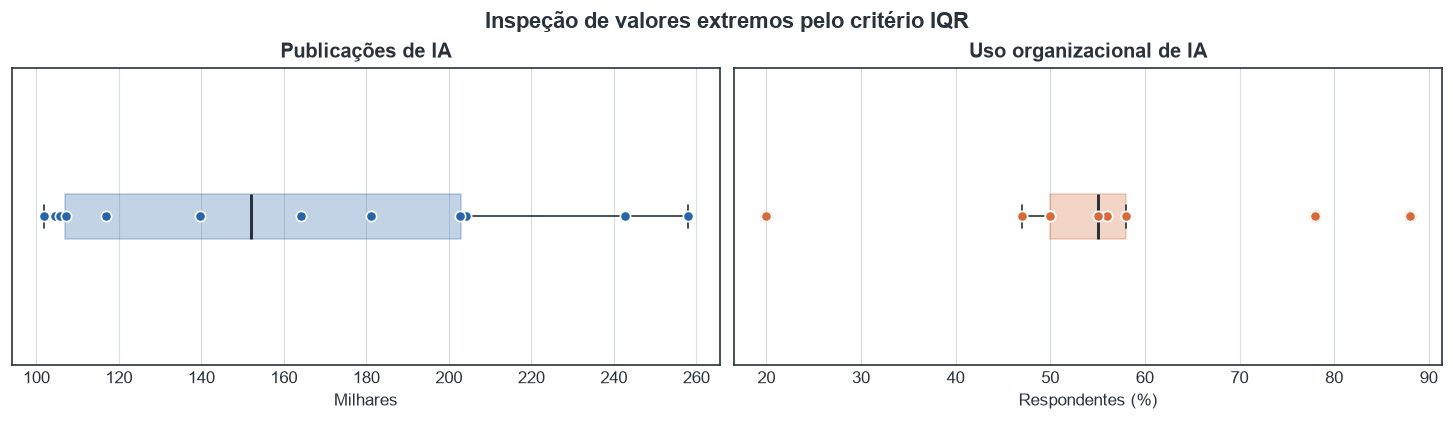

In [6]:
def iqr_diagnostics(frame, year_column, value_column, series_name):
    q1 = frame[value_column].quantile(0.25)
    q3 = frame[value_column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = frame.loc[
        frame[value_column].lt(lower) | frame[value_column].gt(upper),
        [year_column, value_column],
    ]
    return {
        "série": series_name,
        "Q1": q1,
        "Q3": q3,
        "limite_inferior": lower,
        "limite_superior": upper,
        "n_sinalizados": len(flagged),
        "anos_sinalizados": ", ".join(flagged[year_column].astype(str)) or "nenhum",
    }

outlier_summary = pd.DataFrame([
    iqr_diagnostics(
        publication_series,
        "Year",
        "publications_thousands",
        "Publicações (milhares)",
    ),
    iqr_diagnostics(
        adoption_ai,
        "Year",
        "% of respondents",
        "Uso organizacional de IA",
    ),
])
display(outlier_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), constrained_layout=True)
box_specs = [
    (axes[0], publication_series["publications_thousands"], "Publicações de IA", "Milhares", COLORS["blue"]),
    (axes[1], adoption_ai["% of respondents"] * 100, "Uso organizacional de IA", "Respondentes (%)", COLORS["orange"]),
]
for ax, values, title, xlabel, color in box_specs:
    ax.boxplot(
        values,
        orientation="horizontal",
        patch_artist=True,
        boxprops={"facecolor": color, "alpha": 0.28, "edgecolor": color},
        medianprops={"color": COLORS["charcoal"], "linewidth": 1.8},
        whiskerprops={"color": COLORS["charcoal"]},
        capprops={"color": COLORS["charcoal"]},
        flierprops={"markerfacecolor": "white", "markeredgecolor": color, "markersize": 6},
    )
    ax.scatter(values, np.ones(len(values)), color=color, edgecolor="white", s=38, zorder=3)
    ax.set(title=title, xlabel=xlabel, yticks=[])
fig.suptitle("Inspeção de valores extremos pelo critério IQR", fontsize=13, fontweight="bold")
plt.show()


**Decisões de tratamento.** Não há valores ausentes nem duplicatas exatas nos três arquivos selecionados. As repetições de ano são explicadas por métricas ou rótulos distintos. Os anos 2017, 2024 e 2025 são sinalizados na série de adoção pelo IQR, mas são plausíveis no contexto de uma tendência de difusão e não apresentam evidência de erro; por isso foram mantidos. Não foi realizada imputação nem remoção de registros.

Para uma aplicação futura, seria necessário confirmar alterações de questionário, composição da amostra e ponderação em cada edição da pesquisa. Esses aspectos podem introduzir quebras de comparabilidade mesmo quando o arquivo não possui nulos ou duplicatas.


## 4. Resultados

### 4.1 Estatísticas descritivas e alinhamento temporal

A comparação principal usa apenas os anos presentes nas duas séries. Isso evita preencher 2025 com uma publicação ainda não observada ou extrapolar valores.


In [7]:
aligned = (
    publication_series[["Year", "publications_thousands"]]
    .merge(adoption_ai, on="Year", how="inner", validate="one_to_one")
    .sort_values("Year")
)

descriptive = pd.DataFrame({
    "indicador": ["Publicações (milhares)", "Uso organizacional de IA (%)"],
    "n": [publication_series["publications_thousands"].count(), adoption_ai["% of respondents"].count()],
    "mínimo": [publication_series["publications_thousands"].min(), adoption_ai["% of respondents"].min() * 100],
    "mediana": [publication_series["publications_thousands"].median(), adoption_ai["% of respondents"].median() * 100],
    "média": [publication_series["publications_thousands"].mean(), adoption_ai["% of respondents"].mean() * 100],
    "máximo": [publication_series["publications_thousands"].max(), adoption_ai["% of respondents"].max() * 100],
})
display(descriptive.round(2))

print(f"Anos coincidentes: {aligned['Year'].min()}–{aligned['Year'].max()} | n = {len(aligned)}")
display(
    aligned.assign(
        organizational_ai_use_pct=aligned["% of respondents"] * 100
    ).drop(columns="% of respondents")
)


,indicador,n,mínimo,mediana,média,máximo
0,Publicações (milhares),12,101.880,151.960,160.720,257.890
1,Uso organizacional de IA (%),9,20.000,55.000,55.780,88.000


Anos coincidentes: 2017–2024 | n = 8


,Year,publications_thousands,organizational_ai_use_pct
0,2017,116.937,20.000
1,2018,139.711,47.000
2,2019,164.199,58.000
3,2020,181.107,50.000
4,2021,204.054,56.000
5,2022,202.734,50.000
6,2023,242.664,55.000
7,2024,257.891,78.000


### 4.2 Evolução temporal

Os gráficos são separados porque os indicadores possuem unidades e janelas diferentes. A escala percentual permanece de 0% a 100%, evitando exagerar pequenas variações.


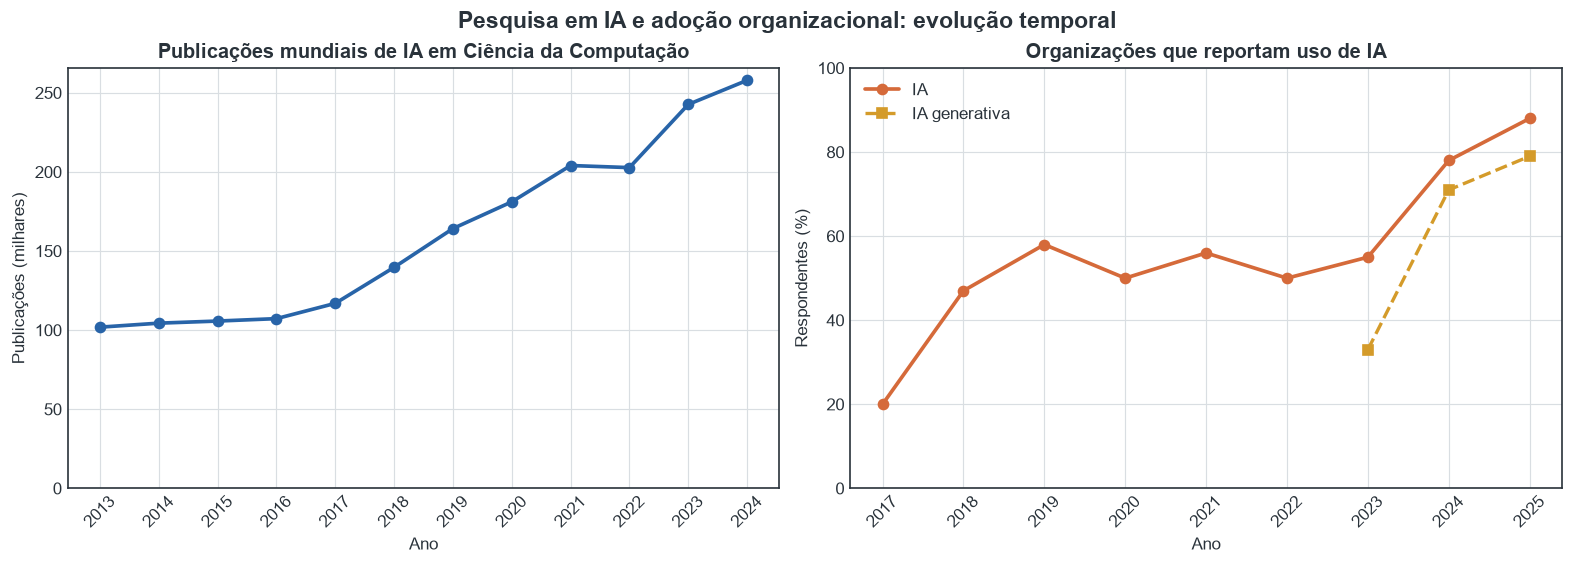

No intervalo coincidente, publicações cresceram 120.5% e o uso organizacional variou +58.0 pontos percentuais.
A adoção apresentou recuos em 2020 e 2022; a produção científica recuou levemente em 2022.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)

axes[0].plot(
    publication_series["Year"],
    publication_series["publications_thousands"],
    color=COLORS["blue"],
    marker="o",
    linewidth=2.2,
    label="Publicações",
)
axes[0].set(
    title="Publicações mundiais de IA em Ciência da Computação",
    xlabel="Ano",
    ylabel="Publicações (milhares)",
    xticks=publication_series["Year"],
)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(bottom=0)

axes[1].plot(
    adoption_ai["Year"],
    adoption_ai["% of respondents"] * 100,
    color=COLORS["orange"],
    marker="o",
    linewidth=2.2,
    label="IA",
)
axes[1].plot(
    adoption_genai["Year"],
    adoption_genai["% of respondents"] * 100,
    color=COLORS["gold"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="IA generativa",
)
axes[1].set(
    title="Organizações que reportam uso de IA",
    xlabel="Ano",
    ylabel="Respondentes (%)",
    xticks=sorted(adoption["Year"].unique()),
    ylim=(0, 100),
)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(frameon=False, loc="upper left")

fig.suptitle("Pesquisa em IA e adoção organizacional: evolução temporal", fontsize=14, fontweight="bold")
plt.show()

publication_growth_pct = (
    aligned["publications_thousands"].iloc[-1] / aligned["publications_thousands"].iloc[0] - 1
) * 100
adoption_change_pp = (
    aligned["% of respondents"].iloc[-1] - aligned["% of respondents"].iloc[0]
) * 100
print(
    f"No intervalo coincidente, publicações cresceram {publication_growth_pct:.1f}% "
    f"e o uso organizacional variou {adoption_change_pp:+.1f} pontos percentuais."
)
print("A adoção apresentou recuos em 2020 e 2022; a produção científica recuou levemente em 2022.")


### 4.3 Associação entre pesquisa e adoção

O diagrama de dispersão usa o ano como rótulo de cada ponto. A linha tracejada é apenas um ajuste linear descritivo e não representa uma previsão causal.


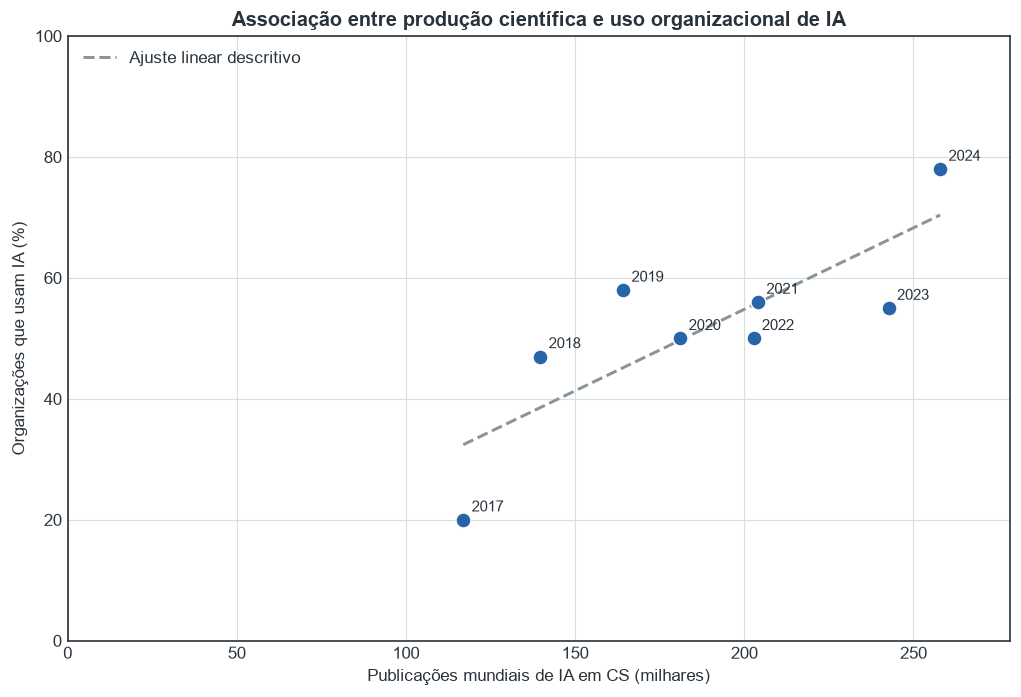

In [9]:
fig, ax = plt.subplots(figsize=(8.4, 5.7), constrained_layout=True)
x = aligned["publications_thousands"].to_numpy()
y = (aligned["% of respondents"] * 100).to_numpy()

ax.scatter(x, y, color=COLORS["blue"], edgecolor="white", linewidth=0.9, s=82, zorder=3)
slope, intercept = np.polyfit(x, y, deg=1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color=COLORS["gray"], linestyle="--", linewidth=1.8, label="Ajuste linear descritivo")

for _, row in aligned.iterrows():
    ax.annotate(
        str(int(row["Year"])),
        (row["publications_thousands"], row["% of respondents"] * 100),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set(
    title="Associação entre produção científica e uso organizacional de IA",
    xlabel="Publicações mundiais de IA em CS (milhares)",
    ylabel="Organizações que usam IA (%)",
    xlim=(0, x.max() * 1.08),
    ylim=(0, 100),
)
ax.legend(frameon=False, loc="upper left")
plt.show()


In [10]:
pearson_levels = aligned["publications_thousands"].corr(
    aligned["% of respondents"], method="pearson"
)
spearman_levels = aligned["publications_thousands"].corr(
    aligned["% of respondents"], method="spearman"
)

annual_changes = (
    aligned.set_index("Year")[["publications_thousands", "% of respondents"]]
    .diff()
    .dropna()
)
pearson_changes = annual_changes["publications_thousands"].corr(
    annual_changes["% of respondents"], method="pearson"
)

leave_one_out = []
for year in aligned["Year"]:
    subset = aligned.loc[aligned["Year"].ne(year)]
    leave_one_out.append(
        subset["publications_thousands"].corr(subset["% of respondents"], method="pearson")
    )

correlations = pd.DataFrame({
    "comparação": ["Níveis anuais", "Níveis anuais", "Variações anuais"],
    "método": ["Pearson", "Spearman", "Pearson"],
    "coeficiente": [pearson_levels, spearman_levels, pearson_changes],
    "n": [len(aligned), len(aligned), len(annual_changes)],
})
display(correlations.round(3))
print(
    "Sensibilidade leave-one-year-out do Pearson em níveis: "
    f"{min(leave_one_out):.2f} a {max(leave_one_out):.2f}."
)


,comparação,método,coeficiente,n
0,Níveis anuais,Pearson,0.813,8
1,Níveis anuais,Spearman,0.731,8
2,Variações anuais,Pearson,0.280,7


Sensibilidade leave-one-year-out do Pearson em níveis: 0.70 a 0.87.


### 4.4 Variações anuais: controle exploratório da tendência comum

Comparar primeiras diferenças não elimina todos os problemas de séries temporais, mas reduz o risco de interpretar duas tendências crescentes como uma relação direta.


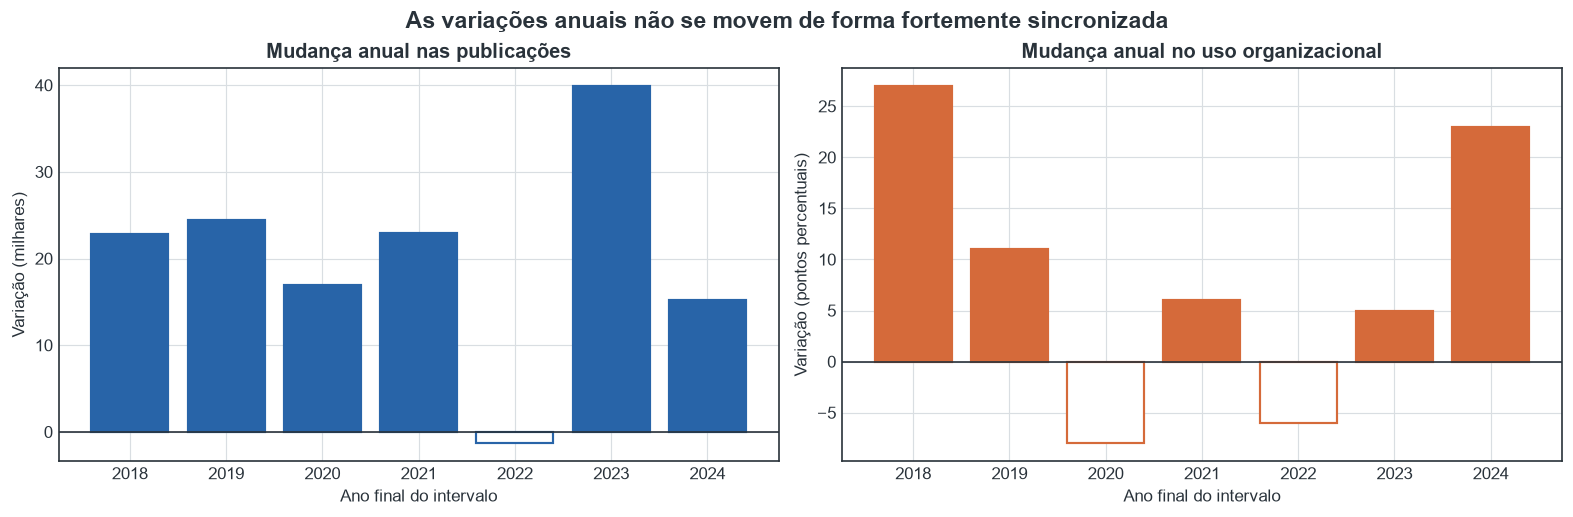

Pearson dos níveis = 0.813 (n=8).
Pearson das variações anuais = 0.280 (n=7).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True, sharex=True)

change_years = annual_changes.index.astype(int)
pub_colors = [COLORS["blue"] if value >= 0 else "white" for value in annual_changes["publications_thousands"]]
adoption_pp = annual_changes["% of respondents"] * 100
adoption_colors = [COLORS["orange"] if value >= 0 else "white" for value in adoption_pp]

axes[0].bar(
    change_years,
    annual_changes["publications_thousands"],
    color=pub_colors,
    edgecolor=COLORS["blue"],
    linewidth=1.3,
)
axes[0].axhline(0, color=COLORS["charcoal"], linewidth=1)
axes[0].set(
    title="Mudança anual nas publicações",
    xlabel="Ano final do intervalo",
    ylabel="Variação (milhares)",
    xticks=change_years,
)

axes[1].bar(
    change_years,
    adoption_pp,
    color=adoption_colors,
    edgecolor=COLORS["orange"],
    linewidth=1.3,
)
axes[1].axhline(0, color=COLORS["charcoal"], linewidth=1)
axes[1].set(
    title="Mudança anual no uso organizacional",
    xlabel="Ano final do intervalo",
    ylabel="Variação (pontos percentuais)",
    xticks=change_years,
)

fig.suptitle("As variações anuais não se movem de forma fortemente sincronizada", fontsize=14, fontweight="bold")
plt.show()

print(f"Pearson dos níveis = {pearson_levels:.3f} (n={len(aligned)}).")
print(f"Pearson das variações anuais = {pearson_changes:.3f} (n={len(annual_changes)}).")


**Interpretação.** O coeficiente de 0,81 nos níveis mostra que anos com maior volume de publicações também tenderam a apresentar maior adoção reportada. Contudo, o coeficiente de 0,28 nas variações anuais é fraco: aumentos maiores de publicações não coincidiram de forma consistente com aumentos maiores de adoção. Esse contraste é compatível com uma correlação de níveis parcialmente impulsionada por tendência temporal comum.

A amostra é pequena e autocorrelacionada; portanto, não usamos o valor-p convencional como evidência decisiva. A análise sustenta uma associação descritiva, não um mecanismo causal.


### 4.5 Quem produz a pesquisa? Composição por setor e região

A figura complementar contextualiza a pesquisa: a academia responde pela maior parcela nas três regiões, enquanto a participação relativa de indústria e governo varia. As participações somam 100% em cada região.


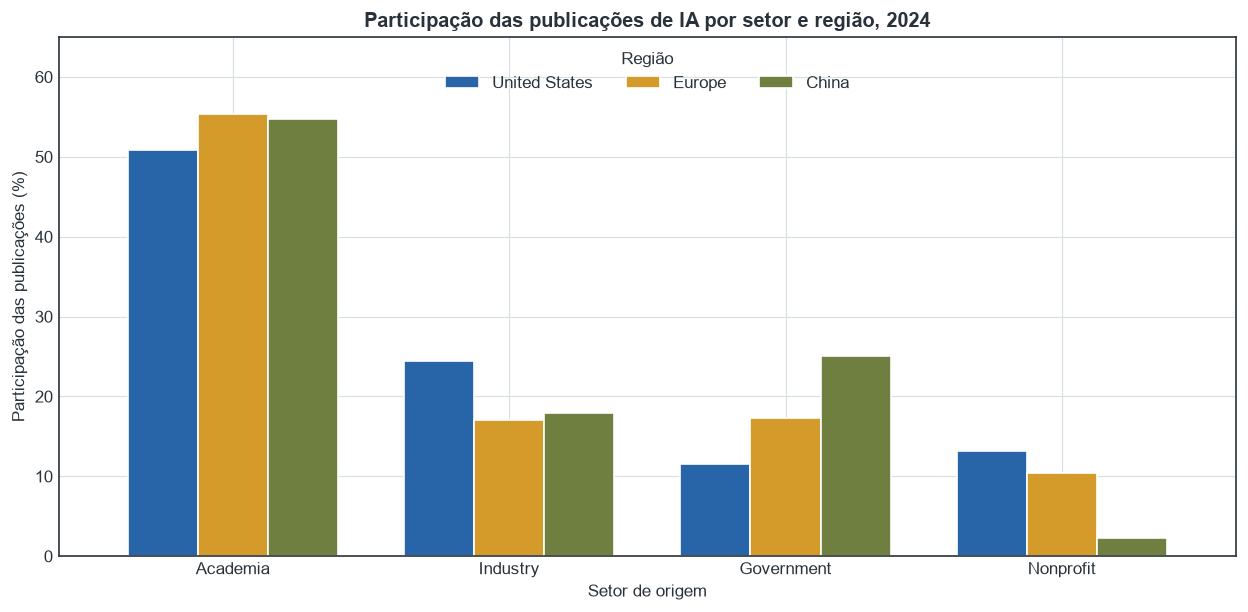

Geographic area,United States,Europe,China
Sector,,,
Academia,50.850,55.300,54.720
Industry,24.460,17.060,17.960
Government,11.580,17.270,25.100
Nonprofit,13.110,10.380,2.220


In [12]:
sector_order = ["Academia", "Industry", "Government", "Nonprofit"]
region_order = ["United States", "Europe", "China"]
sector_pivot = (
    sectors.pivot(index="Sector", columns="Geographic area", values="publication_share")
    .reindex(index=sector_order, columns=region_order)
    * 100
)

ax = sector_pivot.plot(
    kind="bar",
    figsize=(10.5, 5.2),
    color=[COLORS["blue"], COLORS["gold"], COLORS["olive"]],
    width=0.76,
    edgecolor="white",
)
ax.set(
    title="Participação das publicações de IA por setor e região, 2024",
    xlabel="Setor de origem",
    ylabel="Participação das publicações (%)",
    ylim=(0, 65),
)
ax.legend(title="Região", frameon=False, ncol=3, loc="upper center")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

display(sector_pivot.round(2))


## 5. Codificação dos atributos categóricos

`Sector` e `Geographic area` são variáveis **nominais**: suas categorias não possuem ordem natural. Aplicar `OrdinalEncoder` criaria uma hierarquia artificial; por isso usamos **one-hot encoding**.

Mantemos todas as categorias (`drop=None`) para produzir uma representação demonstrativa e facilmente auditável. Em um modelo linear sem regularização, seria apropriado remover uma categoria de referência para evitar colinearidade perfeita. `handle_unknown="ignore"` permite transformar novos dados mesmo quando aparece uma categoria não observada no ajuste.


In [13]:
categorical_columns = ["Sector", "Geographic area"]
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=None)
encoded_values = encoder.fit_transform(sectors[categorical_columns])
encoded_columns = encoder.get_feature_names_out(categorical_columns)
encoded_categories = pd.DataFrame(
    encoded_values,
    columns=encoded_columns,
    index=sectors.index,
).astype(int)

prepared_sectors = pd.concat(
    [sectors[["publication_share"]], encoded_categories],
    axis=1,
)

encoding_comparison = pd.DataFrame({
    "etapa": ["Antes", "Depois"],
    "linhas": [sectors.shape[0], prepared_sectors.shape[0]],
    "colunas": [sectors.shape[1], prepared_sectors.shape[1]],
    "colunas_numéricas": [
        sectors.select_dtypes(include="number").shape[1],
        prepared_sectors.select_dtypes(include="number").shape[1],
    ],
})
display(encoding_comparison)
display(sectors.head(6))
display(prepared_sectors.head(6))
print("Categorias aprendidas:")
for column, categories in zip(categorical_columns, encoder.categories_):
    print(f"- {column}: {', '.join(categories)}")


,etapa,linhas,colunas,colunas_numéricas
0,Antes,12,3,1
1,Depois,12,8,8


,publication_share,Sector,Geographic area
0,0.508,Academia,United States
1,0.245,Industry,United States
2,0.131,Nonprofit,United States
3,0.116,Government,United States
4,0.553,Academia,Europe
5,0.173,Government,Europe


,publication_share,Sector_Academia,Sector_Government,Sector_Industry,Sector_Nonprofit,Geographic area_China,Geographic area_Europe,Geographic area_United States
0,0.508,1,0,0,0,0,0,1
1,0.245,0,0,1,0,0,0,1
2,0.131,0,0,0,1,0,0,1
3,0.116,0,1,0,0,0,0,1
4,0.553,1,0,0,0,0,1,0
5,0.173,0,1,0,0,0,1,0


Categorias aprendidas:
- Sector: Academia, Government, Industry, Nonprofit
- Geographic area: China, Europe, United States


## 6. Conclusões e aplicações futuras

**Resposta à pergunta central.** Entre 2017 e 2024, o volume mundial de publicações de IA em Ciência da Computação e a adoção organizacional reportada cresceram de forma globalmente alinhada. A associação entre os níveis anuais foi positiva e alta (Pearson = 0,81), mas a associação entre as variações anuais foi fraca (Pearson = 0,28). Assim, os dados mostram coexistência temporal entre expansão da pesquisa e difusão corporativa, mas não demonstram que uma tenha causado a outra.

**Principais limitações**

- Apenas oito anos coincidentes e sete variações anuais.
- Indicadores agregados globais, sem pareamento entre pesquisa, países, setores e organizações.
- Publicações medem volume, não qualidade, impacto ou transferência tecnológica.
- Adoção é autorrelatada e pode ser afetada por composição amostral, ponderação e mudanças de questionário.
- Tendência temporal, investimento, disponibilidade de modelos, custo computacional e regulação podem afetar ambas as séries.

**Possível aplicação futura de IA.** Com uma base em painel por país, setor e ano, seria possível estimar ou classificar níveis futuros de adoção a partir de pesquisa, patentes, investimento, capital humano e infraestrutura. `Sector` e `Geographic area` poderiam entrar por one-hot encoding; a validação deveria ser temporal, treinando em anos anteriores e testando em anos posteriores. A base atual é adequada para exploração e preparação, mas pequena e agregada demais para treinar um modelo confiável.

**Próximos passos.** Buscar microdados comparáveis; documentar mudanças metodológicas anuais; adicionar defasagens entre pesquisa e adoção; comparar países ou setores na mesma unidade; e testar robustez com séries mais longas e controles externos.


## 7. Referências e reprodutibilidade

- Stanford Institute for Human-Centered Artificial Intelligence. *The AI Index 2026 Annual Report*. DOI: https://doi.org/10.48550/arXiv.2606.15708.
- Figura 1.6.1: *AI publications in CS worldwide, 2013–24* (relatório, p. 47; arquivo local `fig_1.6.1.csv`).
- Figura 1.6.9: *AI publications in CS (% of total) by sector and geographic area, 2024* (relatório, p. 52; arquivo local `fig_1.6.9.csv`).
- Figura 4.3.1: *Share of respondents who say their organization uses AI in at least one function, 2017–25* (relatório, p. 193; arquivo local `fig_4.3.1(1).csv`).
- Metodologia da pesquisa McKinsey: apêndice do relatório, pp. 396–397.
- Dados públicos e gráficos do relatório: https://drive.google.com/drive/folders/1zJTOg0iR0j5SijCwFutwWvDt143lW277?usp=sharing.

Para reproduzir, mantenha este notebook na pasta que contém `AI_INDEX_REPORT_2026` e execute todas as células em ordem. Versões das bibliotecas usadas são exibidas abaixo.


In [14]:
import sklearn
import matplotlib

versions = pd.Series({
    "Python": __import__("sys").version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "scikit-learn": sklearn.__version__,
}, name="versão")
display(versions.to_frame())


,versão
Python,3.13.14
pandas,3.0.6
numpy,2.5.2
matplotlib,3.11.2
scikit-learn,1.9.1


### Declaração de uso de IA generativa

Foi utilizada uma ferramenta de IA generativa como apoio à seleção do recorte analítico, revisão e organização do código, sugestões de visualização, verificação de consistência e revisão textual. A interpretação final, a validação dos resultados e a responsabilidade pelo conteúdo entregue permanecem com o grupo. Todos os integrantes devem compreender e conseguir explicar o código, os métodos, as escolhas e as conclusões apresentadas.
